# Diffusion inversion + LoRA test notebook

Test notebook with really basic steps:

1. load modelds and schedulers
2. encode image to latents
3. base DDIM inversion
4. recontruction after inversion
5. save and visualize trajectory
6. add LoRA to `UNet` only,
7. test single train step for inversion
8. `baseline` vs `LoRA-enabled inversion`.


In [ ]:
# !pip install -U diffusers transformers accelerate peft safetensors pillow matplotlib ipywidgets

## 1. Imports and config

In [72]:
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionXLPipeline,
    DDIMScheduler,
    DDIMInverseScheduler,
)
from peft import LoraConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

print("DEVICE:", DEVICE)
print("DTYPE:", DTYPE)

DEVICE: cuda
DTYPE: torch.float16


## 2. Experiment configuration

In [ ]:
@dataclass
class ExperimentConfig:
    model_id: str = "runwayml/stable-diffusion-v1-5"
    image_path: str = "example.jpg"
    source_prompt: str = "a photo of a cat sitting on a chair"
    target_prompt: str = "a photo of a dog sitting on a chair"
    negative_prompt: str = ""
    num_inference_steps: int = 100
    guidance_scale: float = 7.5
    height: int = 512
    width: int = 512
    seed: int = 123
    lora_rank: int = 16
    lora_alpha: int = 8
    learning_rate: float = 1e-4

cfg = ExperimentConfig()
cfg

ExperimentConfig(model_id='stabilityai/stable-diffusion-xl-base-1.0', source_prompt='a photo of a cat sitting on a chair', target_prompt='a photo of a dog sitting on a chair', negative_prompt='', num_inference_steps=100, guidance_scale=7.5, height=512, width=512, seed=123, lora_rank=16, lora_alpha=8, learning_rate=0.0001)

## 3. Load pipeline

- standard `DDIMScheduler` for denoising / sampling
- `DDIMInverseScheduler` for inversion
- same `UNet` and `VAE`.

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    cfg.model_id,
    torch_dtype=DTYPE,
    safety_checker=None,
).to(DEVICE)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
inverse_scheduler = DDIMInverseScheduler.from_config(pipe.scheduler.config)

pipe.set_progress_bar_config(disable=False)

print(type(pipe.unet).__name__)
print(type(pipe.scheduler).__name__)
print(type(inverse_scheduler).__name__)

Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The config attributes {'interpolation_type': 'linear', 'use_karras_sigmas': False, 'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


UNet2DConditionModel
DDIMScheduler
DDIMInverseScheduler


## 4. Helper functions

In [75]:
def seed_everything(seed: int) -> torch.Generator:
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return generator

def load_image(path: str, size: tuple[int, int]) -> Image.Image:
    image = Image.open(path).convert("RGB")
    image = image.resize(size, Image.Resampling.LANCZOS)
    return image

def pil_to_numpy(image: Image.Image) -> np.ndarray:
    return np.asarray(image).astype(np.float32) / 255.0

def show_image(image: Image.Image, title: str | None = None):
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 5. Experimental wrapper

In [76]:
class DiffusionInversionWrapper:
    def __init__(self, pipe: StableDiffusionPipeline, inverse_scheduler: DDIMInverseScheduler):
        self.pipe = pipe
        self.unet = pipe.unet
        self.vae = pipe.vae
        self.tokenizer = pipe.tokenizer
        self.text_encoder = pipe.text_encoder
        self.forward_scheduler = pipe.scheduler
        self.inverse_scheduler = inverse_scheduler

    @torch.no_grad()
    def encode_prompt(self, prompt: str, negative_prompt: str = ""):
        text_inputs = self.tokenizer(
            [prompt],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        uncond_inputs = self.tokenizer(
            [negative_prompt],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        text_ids = text_inputs.input_ids.to(DEVICE)
        uncond_ids = uncond_inputs.input_ids.to(DEVICE)

        prompt_embeds = self.text_encoder(text_ids)[0]
        negative_embeds = self.text_encoder(uncond_ids)[0]
        return prompt_embeds, negative_embeds

    @torch.no_grad()
    def encode_image(self, image: Image.Image) -> torch.Tensor:
        image_np = np.asarray(image).astype(np.float32) / 127.5 - 1.0
        image_t = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
        latents = self.vae.encode(image_t).latent_dist.sample()
        latents = latents * self.vae.config.scaling_factor
        return latents

    @torch.no_grad()
    def decode_latents(self, latents: torch.Tensor) -> Image.Image:
        latents = latents / self.vae.config.scaling_factor
        image = self.vae.decode(latents).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image[0].detach().float().cpu().permute(1, 2, 0).numpy()
        image = (image * 255).round().astype(np.uint8)
        return Image.fromarray(image)

    @torch.no_grad()
    def invert(
        self,
        image: Image.Image,
        prompt: str,
        negative_prompt: str = "",
        num_inference_steps: int = 50,
        guidance_scale: float = 1.0,
        return_trajectory: bool = True,
    ):
        latents = self.encode_image(image)
        prompt_embeds, negative_embeds = self.encode_prompt(prompt, negative_prompt)

        self.inverse_scheduler.set_timesteps(num_inference_steps, device=DEVICE)

        trajectory = [latents.detach().clone()] if return_trajectory else None

        for t in self.inverse_scheduler.timesteps:
            latent_model_input = latents
            if guidance_scale != 1.0:
                latent_model_input = torch.cat([latents] * 2)
                encoder_hidden_states = torch.cat([negative_embeds, prompt_embeds], dim=0)
            else:
                encoder_hidden_states = prompt_embeds

            noise_pred = self.unet(
                latent_model_input,
                t,
                encoder_hidden_states=encoder_hidden_states,
            ).sample

            if guidance_scale != 1.0:
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

            latents = self.inverse_scheduler.step(noise_pred, t, latents).prev_sample

            if return_trajectory:
                trajectory.append(latents.detach().clone())

        return latents, trajectory

    @torch.no_grad()
    def sample_from_latents(
        self,
        latents: torch.Tensor,
        prompt: str,
        negative_prompt: str = "",
        num_inference_steps: int = 50,
        guidance_scale: float = 7.5,
        return_trajectory: bool = False,
    ):
        prompt_embeds, negative_embeds = self.encode_prompt(prompt, negative_prompt)
        self.forward_scheduler.set_timesteps(num_inference_steps, device=DEVICE)

        current = latents.clone()
        trajectory = [current.detach().clone()] if return_trajectory else None

        for t in self.forward_scheduler.timesteps:
            latent_model_input = torch.cat([current] * 2)
            encoder_hidden_states = torch.cat([negative_embeds, prompt_embeds], dim=0)

            noise_pred = self.unet(
                latent_model_input,
                t,
                encoder_hidden_states=encoder_hidden_states,
            ).sample

            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

            current = self.forward_scheduler.step(noise_pred, t, current).prev_sample

            if return_trajectory:
                trajectory.append(current.detach().clone())

        image = self.decode_latents(current)
        return image, trajectory

wrapper = DiffusionInversionWrapper(pipe, inverse_scheduler)

## 6. Generate image

  0%|          | 0/100 [00:00<?, ?it/s]

/teamspace/studios/this_studio/Diffusion-Inversion-for-Image-Editing/.venv/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


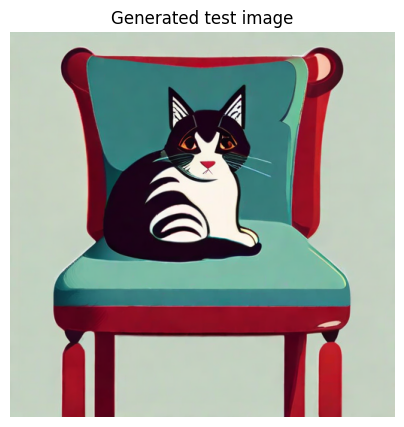

In [77]:
generator = seed_everything(cfg.seed)

result = pipe(
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=cfg.guidance_scale,
    height=cfg.height,
    width=cfg.width,
    generator=generator,
)

image = result.images[0]
show_image(image, "Generated test image")

## 7. Baseline: inversion + reconstruction

- `image -> latents`,
- `invert(...)`,
- `sample_from_latents(...)` with same prompt

In [78]:
generator = seed_everything(cfg.seed)

inv_latents, inv_traj = wrapper.invert(
    image=image,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=1.0,
    return_trajectory=True,
)

recon_image, recon_traj = wrapper.sample_from_latents(
    latents=inv_latents,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=cfg.guidance_scale,
    return_trajectory=True,
)

show_image(recon_image, "Reconstruction after inversion")

TypeError: argument of type 'NoneType' is not iterable

## 8. Check reconstruction

In [ ]:
input_np = pil_to_numpy(image)
recon_np = pil_to_numpy(recon_image)

mse = float(np.mean((input_np - recon_np) ** 2))
psnr = -10.0 * math.log10(max(mse, 1e-12))

print(f"MSE  = {mse:.6f}")
print(f"PSNR = {psnr:.3f} dB")

MSE  = 0.020905
PSNR = 16.797 dB


## 9. Trajectory visualization

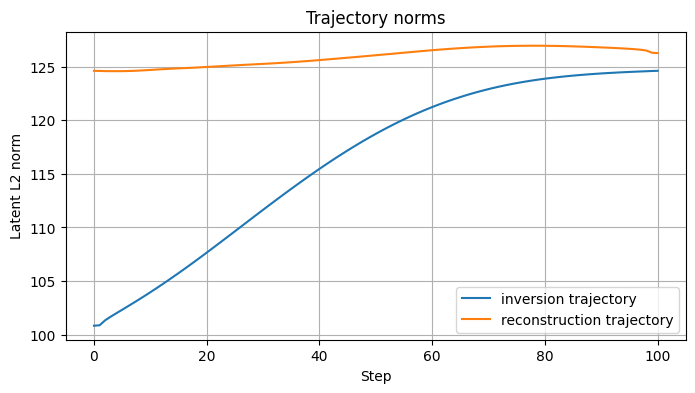

In [60]:
def trajectory_norms(trajectory):
    return [float(x.detach().float().norm().cpu()) for x in trajectory]

inv_norms = trajectory_norms(inv_traj)
rec_norms = trajectory_norms(recon_traj)

plt.figure(figsize=(8, 4))
plt.plot(inv_norms, label="inversion trajectory")
plt.plot(rec_norms, label="reconstruction trajectory")
plt.xlabel("Step")
plt.ylabel("Latent L2 norm")
plt.title("Trajectory norms")
plt.legend()
plt.grid(True)
plt.show()

## 10. Edit after inversion

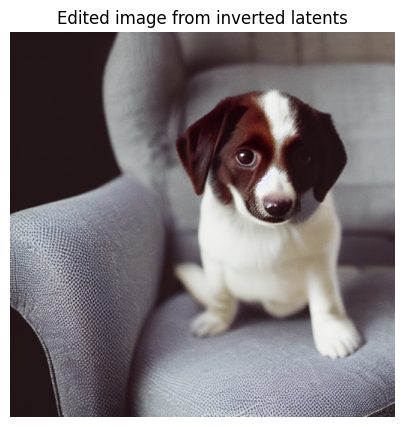

In [61]:
edited_image, _ = wrapper.sample_from_latents(
    latents=inv_latents,
    prompt=cfg.target_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=cfg.guidance_scale,
    return_trajectory=False,
)

show_image(edited_image, "Edited image from inverted latents")

## 11. Add LoRA to UNet

In [62]:
unet_lora_config = LoraConfig(
    r=cfg.lora_rank,
    lora_alpha=cfg.lora_alpha,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

wrapper.unet.add_adapter(unet_lora_config)

for p in wrapper.unet.parameters():
    p.requires_grad_(False)

for name, p in wrapper.unet.named_parameters():
    if "lora" in name.lower():
        p.requires_grad_(True)

trainable = sum(p.numel() for p in wrapper.unet.parameters() if p.requires_grad)
total = sum(p.numel() for p in wrapper.unet.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Total params:     {total:,}")
print(f"Trainable %:      {100 * trainable / total:.4f}%")

Trainable params: 3,188,736
Total params:     862,709,700
Trainable %:      0.3696%


## 12. Functions to on/off adapter

- LoRA `ON` only in `invert(...)`,
- LoRA `OFF` during normal sampling

In [63]:
def set_lora_enabled(unet, enabled: bool = True):
    if enabled:
        if hasattr(unet, "enable_adapters") and callable(unet.enable_adapters):
            unet.enable_adapters()
        else:
            raise AttributeError("UNet does not expose callable enable_adapters().")
    else:
        if hasattr(unet, "disable_adapters") and callable(unet.disable_adapters):
            unet.disable_adapters()
        elif hasattr(unet, "enable_adapters") and callable(unet.enable_adapters):
            # fallback used by some PEFT layers/APIs
            unet.enable_adapters(False)
        else:
            raise AttributeError("UNet does not expose a compatible adapter toggle API.")

## 13. Single step for inversion training

teach LoRA to step from inversion `x_t` goes to real `x_{t+1}`.

In [64]:
optimizer = torch.optim.AdamW(
    [p for p in wrapper.unet.parameters() if p.requires_grad],
    lr=cfg.learning_rate,
)

def single_inversion_training_step(
    x_t: torch.Tensor,
    x_tp1_gt: torch.Tensor,
    t: torch.Tensor | int,
    prompt: str,
    negative_prompt: str = "",
):
    wrapper.unet.train()
    optimizer.zero_grad()

    prompt_embeds, _ = wrapper.encode_prompt(prompt, negative_prompt)

    noise_pred = wrapper.unet(
        x_t,
        t,
        encoder_hidden_states=prompt_embeds,
    ).sample

    x_tp1_pred = wrapper.inverse_scheduler.step(noise_pred, t, x_t).prev_sample
    loss = F.mse_loss(x_tp1_pred.float(), x_tp1_gt.float())

    loss.backward()
    optimizer.step()


    with torch.no_grad():
        diff = (x_tp1_pred - x_tp1_gt).abs()
        print("max abs diff:", diff.max().item())
        print("mean abs diff:", diff.mean().item())

    return float(loss.detach().cpu())

## 14. Artifical one batch test

In [65]:
x_t = inv_traj[0].detach().clone().requires_grad_(False)
x_tp1_gt = inv_traj[1].detach().clone().requires_grad_(False)
timestep = wrapper.inverse_scheduler.timesteps[0]

loss_value = single_inversion_training_step(
    x_t=x_t,
    x_tp1_gt=x_tp1_gt,
    t=timestep,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
)

print("Single-step training loss:", loss_value)

max abs diff: 0.0
mean abs diff: 0.0
Single-step training loss: 0.0


## 15. Compare inversion with and without adapter

/tmp/ipykernel_16625/736446564.py:48: RuntimeWarning: invalid value encountered in cast
  image = (image * 255).round().astype(np.uint8)


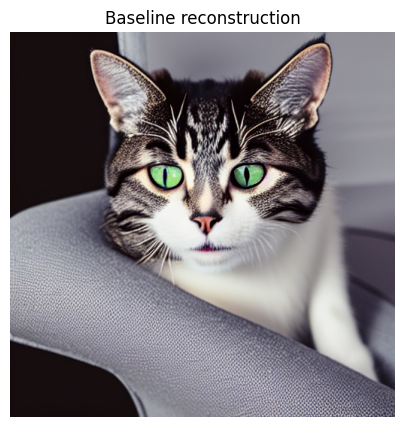

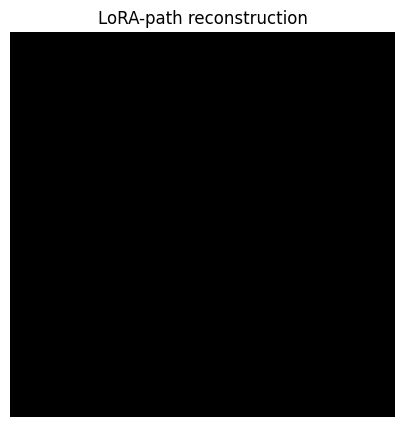

In [66]:
# OFF
set_lora_enabled(wrapper.unet, False)
baseline_inv_latents, _ = wrapper.invert(
    image=image,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=1.0,
    return_trajectory=False,
)

baseline_recon, _ = wrapper.sample_from_latents(
    latents=baseline_inv_latents,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=cfg.guidance_scale,
)

# ON
set_lora_enabled(wrapper.unet, True)
lora_inv_latents, _ = wrapper.invert(
    image=image,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=1.0,
    return_trajectory=False,
)

set_lora_enabled(wrapper.unet, False)
lora_recon, _ = wrapper.sample_from_latents(
    latents=lora_inv_latents,
    prompt=cfg.source_prompt,
    negative_prompt=cfg.negative_prompt,
    num_inference_steps=cfg.num_inference_steps,
    guidance_scale=cfg.guidance_scale,
)

show_image(baseline_recon, "Baseline reconstruction")
show_image(lora_recon, "LoRA-path reconstruction")

## 16. Train dataset

Fields of one data sample:
- `latents_t`
- `latents_tp1`
- `timestep`
- `prompt`

In [18]:
example_batch = {
    "latents_t": torch.randn(1, 4, cfg.height // 8, cfg.width // 8, device=DEVICE, dtype=DTYPE),
    "latents_tp1": torch.randn(1, 4, cfg.height // 8, cfg.width // 8, device=DEVICE, dtype=DTYPE),
    "timestep": torch.tensor(999, device=DEVICE),
    "prompt": cfg.source_prompt,
}
{k: (v.shape if torch.is_tensor(v) else v) for k, v in example_batch.items()}

{'latents_t': torch.Size([1, 4, 64, 64]),
 'latents_tp1': torch.Size([1, 4, 64, 64]),
 'timestep': torch.Size([]),
 'prompt': 'a photo of a cat sitting on a chair'}